<a href="https://colab.research.google.com/github/suneetaramanathan/TrustNest/blob/main/TrustNest_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install scikit-learn pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Create fake hotel data
# This simulates normal hotel activity + some suspicious activity

np.random.seed(42)

# Normal activity — staff accessing guest records normally
normal_access = np.random.normal(loc=10, scale=2, size=200)

# Suspicious activity — someone accessing too many records
suspicious_access = np.random.normal(loc=50, scale=5, size=10)

# Combine all activity
all_activity = np.concatenate([normal_access, suspicious_access])

# Create a dataframe
df = pd.DataFrame({
    'records_accessed': all_activity,
    'hour_of_day': np.random.randint(0, 24, size=210)
})

print("Hotel data created!")
print(f"Total activities: {len(df)}")
print(f"Sample data:")
print(df.head(10))

Hotel data created!
Total activities: 210
Sample data:
   records_accessed  hour_of_day
0         10.993428           12
1          9.723471           19
2         11.295377            0
3         13.046060            7
4          9.531693           13
5          9.531726           15
6         13.158426           13
7         11.534869           11
8          9.061051           18
9         11.085120           22


In [4]:
# Build the Anomaly Detection Model
model = IsolationForest(contamination=0.05, random_state=42)

# Train the model on hotel activity data
X = df[['records_accessed', 'hour_of_day']]
df['anomaly'] = model.fit_predict(X)

# -1 means suspicious, 1 means normal
df['status'] = df['anomaly'].map({1: 'NORMAL', -1: 'SUSPICIOUS'})

# Show results
normal = len(df[df['status'] == 'NORMAL'])
suspicious = len(df[df['status'] == 'SUSPICIOUS'])

print("=" * 40)
print("   TRUSTNEST SECURITY SCAN RESULTS")
print("=" * 40)
print(f"Total Activities Scanned: {len(df)}")
print(f"Normal Activities:        {normal} ✅")
print(f"Suspicious Activities:    {suspicious} 🚨")
print("=" * 40)

if suspicious > 0:
    print("\n⚠️  ALERT: Suspicious activity detected!")
    print("\nSuspicious records:")
    print(df[df['status'] == 'SUSPICIOUS'][['records_accessed', 'hour_of_day', 'status']].head(10))

   TRUSTNEST SECURITY SCAN RESULTS
Total Activities Scanned: 210
Normal Activities:        199 ✅
Suspicious Activities:    11 🚨

⚠️  ALERT: Suspicious activity detected!

Suspicious records:
     records_accessed  hour_of_day      status
125         14.380911            0  SUSPICIOUS
200         51.788937           11  SUSPICIOUS
201         52.803923           19  SUSPICIOUS
202         55.415256           20  SUSPICIOUS
203         55.269010            3  SUSPICIOUS
204         43.111653           20  SUSPICIOUS
205         45.310875           22  SUSPICIOUS
206         52.575176           15  SUSPICIOUS
207         52.568930            6  SUSPICIOUS
208         52.575238           12  SUSPICIOUS


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


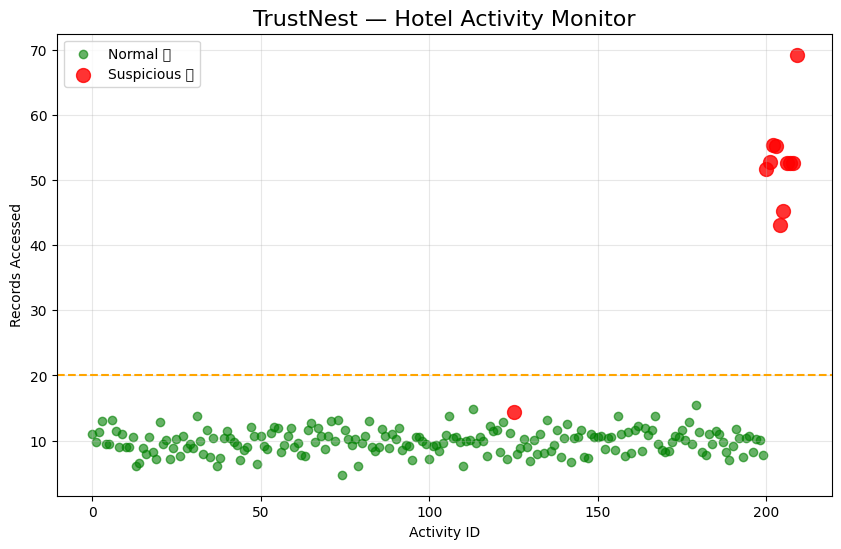

Dashboard generated!


In [5]:
# Visualise the results
plt.figure(figsize=(10, 6))

# Plot normal activity
normal_data = df[df['status'] == 'NORMAL']
suspicious_data = df[df['status'] == 'SUSPICIOUS']

plt.scatter(normal_data.index, normal_data['records_accessed'],
            color='green', label='Normal ✅', alpha=0.6)
plt.scatter(suspicious_data.index, suspicious_data['records_accessed'],
            color='red', label='Suspicious 🚨', alpha=0.8, s=100)

plt.title('TrustNest — Hotel Activity Monitor', fontsize=16)
plt.xlabel('Activity ID')
plt.ylabel('Records Accessed')
plt.legend()
plt.axhline(y=20, color='orange', linestyle='--', label='Threshold')
plt.grid(True, alpha=0.3)
plt.show()

print("Dashboard generated!")

In [6]:
# TrustNest — Real Time Alert System

import datetime

def check_activity(staff_name, records_accessed):
    """
    Checks if staff activity is suspicious
    and sends an alert if needed
    """

    # Run through our model
    activity = np.array([[records_accessed,
                         datetime.datetime.now().hour]])
    prediction = model.predict(activity)

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    print("=" * 50)
    print("   TRUSTNEST REAL TIME MONITOR")
    print("=" * 50)
    print(f"Timestamp:        {timestamp}")
    print(f"Staff Member:     {staff_name}")
    print(f"Records Accessed: {records_accessed}")

    if prediction[0] == -1:
        print(f"Status:           🚨 SUSPICIOUS ACTIVITY!")
        print(f"ACTION:           Alert sent to manager!")
    else:
        print(f"Status:           ✅ Normal Activity")
    print("=" * 50)

# Test with different staff members
check_activity("Maria Schmidt", 8)   # Normal
check_activity("John Mueller", 52)   # Suspicious!
check_activity("Anna Weber", 11)     # Normal
check_activity("Unknown User", 67)   # Very suspicious!

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 00:33:30
Staff Member:     Maria Schmidt
Records Accessed: 8
Status:           ✅ Normal Activity
   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 00:33:30
Staff Member:     John Mueller
Records Accessed: 52
Status:           🚨 SUSPICIOUS ACTIVITY!
ACTION:           Alert sent to manager!
   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 00:33:30
Staff Member:     Anna Weber
Records Accessed: 11
Status:           ✅ Normal Activity
   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 00:33:30
Staff Member:     Unknown User
Records Accessed: 67
Status:           🚨 SUSPICIOUS ACTIVITY!
ACTION:           Alert sent to manager!


In [7]:
# Fixed version - removes the warnings
def check_activity_v2(staff_name, records_accessed):

    import datetime

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Fix - use proper dataframe format
    activity = pd.DataFrame({
        'records_accessed': [records_accessed],
        'hour_of_day': [datetime.datetime.now().hour]
    })

    prediction = model.predict(activity)

    print("=" * 50)
    print("   TRUSTNEST REAL TIME MONITOR")
    print("=" * 50)
    print(f"Timestamp:        {timestamp}")
    print(f"Staff Member:     {staff_name}")
    print(f"Records Accessed: {records_accessed}")

    if prediction[0] == -1:
        print(f"Status:           🚨 SUSPICIOUS ACTIVITY!")
        print(f"ACTION:           Alert sent to manager!")
    else:
        print(f"Status:           ✅ Normal Activity")
    print("=" * 50)

# Test again
check_activity_v2("Maria Schmidt", 8)
check_activity_v2("John Mueller", 52)

   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 00:33:30
Staff Member:     Maria Schmidt
Records Accessed: 8
Status:           ✅ Normal Activity
   TRUSTNEST REAL TIME MONITOR
Timestamp:        2026-05-30 00:33:31
Staff Member:     John Mueller
Records Accessed: 52
Status:           🚨 SUSPICIOUS ACTIVITY!
ACTION:           Alert sent to manager!


In [8]:
# TrustNest — Email Alert Simulator
# (Simulates sending email to hotel manager)

def send_alert_email(staff_name, records_accessed, timestamp):

    email_content = f"""
    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: {staff_name}
    - Records Accessed: {records_accessed}
    - Time: {timestamp}
    - Risk Level: HIGH

    Please investigate immediately.

    TrustNest Security System
    """

    print(email_content)
    print("✅ Alert email sent to manager!")

# Test it
import datetime
send_alert_email(
    "John Mueller",
    52,
    datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
)


    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: John Mueller
    - Records Accessed: 52
    - Time: 2026-05-30 00:33:31
    - Risk Level: HIGH

    Please investigate immediately.

    TrustNest Security System
    
✅ Alert email sent to manager!


In [9]:
# TRUSTNEST — Complete Security System v1.0

def trustnest_monitor(staff_name, records_accessed):

    import datetime
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Check activity
    activity = pd.DataFrame({
        'records_accessed': [records_accessed],
        'hour_of_day': [datetime.datetime.now().hour]
    })

    prediction = model.predict(activity)

    if prediction[0] == -1:
        print(f"🚨 ALERT: {staff_name} accessed {records_accessed} records at {timestamp}")
        send_alert_email(staff_name, records_accessed, timestamp)
    else:
        print(f"✅ NORMAL: {staff_name} accessed {records_accessed} records at {timestamp}")

# Simulate a full day of hotel activity
print("TRUSTNEST MONITORING SYSTEM — LIVE")
print("=" * 50)
trustnest_monitor("Anna Weber", 9)
trustnest_monitor("John Mueller", 55)
trustnest_monitor("Maria Schmidt", 12)
trustnest_monitor("Unknown User", 71)
trustnest_monitor("Peter Klein", 8)

TRUSTNEST MONITORING SYSTEM — LIVE
✅ NORMAL: Anna Weber accessed 9 records at 2026-05-30 00:33:31
🚨 ALERT: John Mueller accessed 55 records at 2026-05-30 00:33:31

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: John Mueller
    - Records Accessed: 55
    - Time: 2026-05-30 00:33:31
    - Risk Level: HIGH

    Please investigate immediately.

    TrustNest Security System
    
✅ Alert email sent to manager!
✅ NORMAL: Maria Schmidt accessed 12 records at 2026-05-30 00:33:31
🚨 ALERT: Unknown User accessed 71 records at 2026-05-30 00:33:31

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: Unknown User
    -

In [10]:
# TrustNest — Login Security Monitor

import datetime

def monitor_login(staff_name, failed_attempts, login_hour):

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Suspicious if more than 3 failed attempts
    # or logging in between 2am and 5am

    suspicious = False
    reason = []

    if failed_attempts > 3:
        suspicious = True
        reason.append(f"{failed_attempts} failed login attempts")

    if login_hour >= 2 and login_hour <= 5:
        suspicious = True
        reason.append(f"unusual login time ({login_hour}:00am)")

    print("=" * 50)
    print(f"Staff:    {staff_name}")
    print(f"Time:     {timestamp}")
    print(f"Failed attempts: {failed_attempts}")

    if suspicious:
        print(f"Status:   🚨 SUSPICIOUS!")
        for r in reason:
            print(f"Reason:   {r}")
        send_alert_email(staff_name, failed_attempts, timestamp)
    else:
        print(f"Status:   ✅ Normal")
    print("=" * 50)

# Test it
monitor_login("Anna Weber", 1, 9)      # Normal
monitor_login("Unknown User", 8, 3)    # Suspicious — too many attempts + odd hour
monitor_login("John Mueller", 5, 14)   # Suspicious — too many attempts
monitor_login("Maria Schmidt", 0, 8)   # Normal

Staff:    Anna Weber
Time:     2026-05-30 00:33:31
Failed attempts: 1
Status:   ✅ Normal
Staff:    Unknown User
Time:     2026-05-30 00:33:31
Failed attempts: 8
Status:   🚨 SUSPICIOUS!
Reason:   8 failed login attempts
Reason:   unusual login time (3:00am)

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: Unknown User
    - Records Accessed: 8
    - Time: 2026-05-30 00:33:31
    - Risk Level: HIGH

    Please investigate immediately.

    TrustNest Security System
    
✅ Alert email sent to manager!
Staff:    John Mueller
Time:     2026-05-30 00:33:31
Failed attempts: 5
Status:   🚨 SUSPICIOUS!
Reason:   5 failed login attempts

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detect

In [11]:
# TrustNest — Data Download Monitor

def monitor_download(staff_name, download_size_mb):

    import datetime
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Suspicious if download is over 100MB
    print("=" * 50)
    print(f"Staff:     {staff_name}")
    print(f"Download:  {download_size_mb} MB")
    print(f"Time:      {timestamp}")

    if download_size_mb > 100:
        print(f"Status:    🚨 SUSPICIOUS DOWNLOAD!")
        print(f"Reason:    Large data export detected")
        send_alert_email(staff_name, download_size_mb, timestamp)
    else:
        print(f"Status:    ✅ Normal Download")
    print("=" * 50)

# Test it
monitor_download("Anna Weber", 25)      # Normal
monitor_download("Unknown User", 450)   # Suspicious!
monitor_download("John Mueller", 80)    # Normal
monitor_download("Peter Klein", 200)    # Suspicious!

Staff:     Anna Weber
Download:  25 MB
Time:      2026-05-30 00:33:31
Status:    ✅ Normal Download
Staff:     Unknown User
Download:  450 MB
Time:      2026-05-30 00:33:31
Status:    🚨 SUSPICIOUS DOWNLOAD!
Reason:    Large data export detected

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: Unknown User
    - Records Accessed: 450
    - Time: 2026-05-30 00:33:31
    - Risk Level: HIGH

    Please investigate immediately.

    TrustNest Security System
    
✅ Alert email sent to manager!
Staff:     John Mueller
Download:  80 MB
Time:      2026-05-30 00:33:31
Status:    ✅ Normal Download
Staff:     Peter Klein
Download:  200 MB
Time:      2026-05-30 00:33:31
Status:    🚨 SUSPICIOUS DOWNLOAD!
Reason:    Large data export detected

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUB

In [12]:
# TRUSTNEST v1.0 — Complete Security System

def trustnest_full_scan(staff_name, records_accessed,
                         failed_logins, login_hour,
                         download_mb):

    print("\n" + "=" * 50)
    print("   🔐 TRUSTNEST COMPLETE SECURITY SCAN")
    print("=" * 50)
    print(f"Staff: {staff_name}")
    print("-" * 50)

    # Run all 3 checks
    monitor_login(staff_name, failed_logins, login_hour)
    trustnest_monitor(staff_name, records_accessed)
    monitor_download(staff_name, download_mb)

    print("=" * 50)
    print("   SCAN COMPLETE")
    print("=" * 50)

# Test full system
trustnest_full_scan("Anna Weber", 9, 1, 9, 25)
trustnest_full_scan("Unknown Hacker", 71, 8, 3, 450)


   🔐 TRUSTNEST COMPLETE SECURITY SCAN
Staff: Anna Weber
--------------------------------------------------
Staff:    Anna Weber
Time:     2026-05-30 00:33:31
Failed attempts: 1
Status:   ✅ Normal
✅ NORMAL: Anna Weber accessed 9 records at 2026-05-30 00:33:31
Staff:     Anna Weber
Download:  25 MB
Time:      2026-05-30 00:33:31
Status:    ✅ Normal Download
   SCAN COMPLETE

   🔐 TRUSTNEST COMPLETE SECURITY SCAN
Staff: Unknown Hacker
--------------------------------------------------
Staff:    Unknown Hacker
Time:     2026-05-30 00:33:31
Failed attempts: 8
Status:   🚨 SUSPICIOUS!
Reason:   8 failed login attempts
Reason:   unusual login time (3:00am)

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: Unknown Hacker
    - Records Accessed: 8
    - Time: 2026-05-30 00:33:31
    - Risk Level: HIGH

 

In [13]:
# Install Flask for web interface
!pip install flask pyngrok

In [14]:
from flask import Flask, render_template_string
import datetime

app = Flask(__name__)

# HTML template for TrustNest dashboard
HTML_TEMPLATE = """
<!DOCTYPE html>
<html>
<head>
    <title>TrustNest Security Dashboard</title>
    <style>
        body { font-family: Arial; background: #1a1a2e; color: white; padding: 20px; }
        h1 { color: #00d4ff; text-align: center; }
        .alert { background: #ff4444; padding: 15px; margin: 10px; border-radius: 8px; }
        .normal { background: #00aa44; padding: 15px; margin: 10px; border-radius: 8px; }
        .header { text-align: center; padding: 20px; border-bottom: 2px solid #00d4ff; }
    </style>
</head>
<body>
    <div class="header">
        <h1>🔐 TrustNest Security Dashboard</h1>
        <p>AI-Powered Hotel Cybersecurity Platform</p>
    </div>

    <h2>Recent Activity:</h2>
    {% for activity in activities %}
        {% if activity.suspicious %}
            <div class="alert">
                🚨 SUSPICIOUS: {{ activity.name }} —
                {{ activity.records }} records at {{ activity.time }}
            </div>
        {% else %}
            <div class="normal">
                ✅ NORMAL: {{ activity.name }} —
                {{ activity.records }} records at {{ activity.time }}
            </div>
        {% endif %}
    {% endfor %}
</body>
</html>
"""

@app.route('/')
def dashboard():
    activities = [
        {"name": "Anna Weber", "records": 9, "suspicious": False,
         "time": datetime.datetime.now().strftime("%H:%M:%S")},
        {"name": "Unknown Hacker", "records": 71, "suspicious": True,
         "time": datetime.datetime.now().strftime("%H:%M:%S")},
        {"name": "Maria Schmidt", "records": 12, "suspicious": False,
         "time": datetime.datetime.now().strftime("%H:%M:%S")},
        {"name": "John Mueller", "records": 55, "suspicious": True,
         "time": datetime.datetime.now().strftime("%H:%M:%S")},
    ]
    return render_template_string(HTML_TEMPLATE, activities=activities)

print("TrustNest Dashboard ready!")

TrustNest Dashboard ready!


In [15]:
from pyngrok import ngrok
ngrok.set_auth_token("3EQ2bz70990L2Fh5t7iAcsAllpO_3mpEGiRiLSH7hbGM57ErP")
print("Token set successfully!")

Token set successfully!


In [16]:
import threading

def run_app():
    app.run(port=5000, use_reloader=False)

thread = threading.Thread(target=run_app)
thread.daemon = True
thread.start()

public_url = ngrok.connect(5000)
print(f"TrustNest is LIVE!")
print(f"Open this link: {public_url}")


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


TrustNest is LIVE!
Open this link: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5000"


In [17]:
# Install database library
!pip install sqlalchemy

In [18]:
from sqlalchemy import create_engine, Column, Integer, String, DateTime, Boolean
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
import datetime

# Create database
engine = create_engine('sqlite:///trustnest.db')
Base = declarative_base()

# Create security alerts table
class SecurityAlert(Base):
    __tablename__ = 'security_alerts'

    id = Column(Integer, primary_key=True)
    staff_name = Column(String)
    activity_type = Column(String)
    value = Column(Integer)
    suspicious = Column(Boolean)
    timestamp = Column(DateTime, default=datetime.datetime.now)

# Create the table
Base.metadata.create_all(engine)
Session = sessionmaker(bind=engine)
session = Session()

print("✅ TrustNest Database created successfully!")

✅ TrustNest Database created successfully!


/tmp/ipykernel_45952/1311396656.py:8: MovedIn20Warning: The ``declarative_base()`` function is now available as sqlalchemy.orm.declarative_base(). (deprecated since: 2.0) (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  Base = declarative_base()


In [19]:
# Save security alerts to database

def save_alert(staff_name, activity_type, value, suspicious):
    alert = SecurityAlert(
        staff_name=staff_name,
        activity_type=activity_type,
        value=value,
        suspicious=suspicious,
        timestamp=datetime.datetime.now()
    )
    session.add(alert)
    session.commit()
    print(f"✅ Saved to database: {staff_name} — {activity_type}")

# Test saving alerts
save_alert("Anna Weber", "records_accessed", 9, False)
save_alert("Unknown Hacker", "records_accessed", 71, True)
save_alert("John Mueller", "login_attempts", 5, True)
save_alert("Maria Schmidt", "download_mb", 25, False)

print("\n✅ All alerts saved to TrustNest database!")

✅ Saved to database: Anna Weber — records_accessed
✅ Saved to database: Unknown Hacker — records_accessed
✅ Saved to database: John Mueller — login_attempts
✅ Saved to database: Maria Schmidt — download_mb

✅ All alerts saved to TrustNest database!


In [20]:
# Read all alerts from database

def show_all_alerts():
    alerts = session.query(SecurityAlert).all()

    print("=" * 50)
    print("   📊 TRUSTNEST DATABASE REPORT")
    print("=" * 50)

    for alert in alerts:
        if alert.suspicious:
            print(f"🚨 SUSPICIOUS | {alert.staff_name} | "
                  f"{alert.activity_type} | "
                  f"Value: {alert.value} | "
                  f"Time: {alert.timestamp.strftime('%H:%M:%S')}")
        else:
            print(f"✅ NORMAL    | {alert.staff_name} | "
                  f"{alert.activity_type} | "
                  f"Value: {alert.value} | "
                  f"Time: {alert.timestamp.strftime('%H:%M:%S')}")

    print("=" * 50)
    total = len(alerts)
    suspicious = len([a for a in alerts if a.suspicious])
    print(f"Total Alerts: {total} | Suspicious: {suspicious}")
    print("=" * 50)

show_all_alerts()

   📊 TRUSTNEST DATABASE REPORT
✅ NORMAL    | Anna Weber | records_accessed | Value: 9 | Time: 23:23:21
🚨 SUSPICIOUS | Unknown Hacker | records_accessed | Value: 71 | Time: 23:23:21
🚨 SUSPICIOUS | John Mueller | login_attempts | Value: 5 | Time: 23:23:21
✅ NORMAL    | Maria Schmidt | download_mb | Value: 25 | Time: 23:23:21
🚨 SUSPICIOUS | Unknown Hacker | full_scan | Value: 71 | Time: 23:27:47
✅ NORMAL    | Anna Weber | records_accessed | Value: 9 | Time: 00:14:13
🚨 SUSPICIOUS | Unknown Hacker | records_accessed | Value: 71 | Time: 00:14:13
🚨 SUSPICIOUS | John Mueller | login_attempts | Value: 5 | Time: 00:14:13
✅ NORMAL    | Maria Schmidt | download_mb | Value: 25 | Time: 00:14:13
✅ NORMAL    | Anna Weber | records_accessed | Value: 9 | Time: 00:34:00
🚨 SUSPICIOUS | Unknown Hacker | records_accessed | Value: 71 | Time: 00:34:00
🚨 SUSPICIOUS | John Mueller | login_attempts | Value: 5 | Time: 00:34:00
✅ NORMAL    | Maria Schmidt | download_mb | Value: 25 | Time: 00:34:00
Total Alerts: 13

In [27]:
from sqlalchemy import create_engine, Column, Integer, String, DateTime, Boolean
from sqlalchemy.orm import declarative_base, sessionmaker
import datetime

engine = create_engine('sqlite:///trustnest.db')
Base = declarative_base()

class SecurityAlert(Base):
    __tablename__ = 'security_alerts'
    __table_args__ = {'extend_existing': True}

    id = Column(Integer, primary_key=True)
    staff_name = Column(String)
    activity_type = Column(String)
    value = Column(Integer)
    suspicious = Column(Boolean)
    timestamp = Column(DateTime, default=datetime.datetime.now)

class HotelUser(Base):
    __tablename__ = 'hotel_users'
    __table_args__ = {'extend_existing': True}

    id = Column(Integer, primary_key=True)
    hotel_name = Column(String)
    username = Column(String)
    password_hash = Column(String)
    created_at = Column(DateTime, default=datetime.datetime.now)

Base.metadata.create_all(engine)
Session = sessionmaker(bind=engine)
session = Session()

print("✅ Database ready!")

✅ Database ready!


In [28]:
# TRUSTNEST COMPLETE SYSTEM v2.0

def trustnest_complete(username, password, staff_name,
                        records_accessed, failed_logins,
                        login_hour, download_mb):

    print("=" * 50)
    print("   🔐 TRUSTNEST v2.0 — FULL SYSTEM")
    print("=" * 50)

    # Step 1 — Verify hotel login
    if not login(username, password):
        print("❌ Access denied!")
        return

    # Step 2 — Run security scan
    trustnest_full_scan(staff_name, records_accessed,
                        failed_logins, login_hour, download_mb)

    # Step 3 — Save to database
    suspicious = records_accessed > 20 or failed_logins > 3
    save_alert(staff_name, "full_scan", records_accessed, suspicious)

    print("✅ Report saved to database!")
    print("=" * 50)

# Test complete system
trustnest_complete(
    "munich_manager", "secure123",
    "Unknown Hacker", 71, 8, 3, 450
)

   🔐 TRUSTNEST v2.0 — FULL SYSTEM
✅ Login successful! Welcome Hotel Munich!

   🔐 TRUSTNEST COMPLETE SECURITY SCAN
Staff: Unknown Hacker
--------------------------------------------------
Staff:    Unknown Hacker
Time:     2026-05-30 00:37:58
Failed attempts: 8
Status:   🚨 SUSPICIOUS!
Reason:   8 failed login attempts
Reason:   unusual login time (3:00am)

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear Hotel Manager,

    TrustNest has detected suspicious activity in your system.

    Details:
    - Staff Member: Unknown Hacker
    - Records Accessed: 8
    - Time: 2026-05-30 00:37:58
    - Risk Level: HIGH

    Please investigate immediately.

    TrustNest Security System
    
✅ Alert email sent to manager!
🚨 ALERT: Unknown Hacker accessed 71 records at 2026-05-30 00:37:58

    FROM: trustnest@security.com
    TO: manager@hotel.com
    SUBJECT: 🚨 SECURITY ALERT - Suspicious Activity Detected

    Dear 

In [30]:
# 🔐 TrustNest
## AI-Powered Cybersecurity Platform for Hotels

### What is TrustNest?
TrustNest is a B2B SaaS platform that protects independent hotels
from cybersecurity threats using artificial intelligence.

### The Problem
- 53% of hotel managers surveyed experienced data breaches
- Independent hotels can't afford expensive security systems
- Guest data is at risk every day

### Our Solution
TrustNest monitors hotel systems 24/7 using AI to:
- Detect suspicious staff activity
- Monitor login failures
- Track unusual data downloads
- Send instant alerts to managers

### Technology Stack
- Python & Scikit-learn (AI Model)
- Flask (Web Interface)
- SQLite (Database)
- Hugging Face (NLP)
- Microsoft Fabric (Data Pipeline)

### Market
- German hospitality market: €78.5 billion
- Target: 50,000+ independent hotels in Germany

### Business Model
- Basic: €500/month per hotel
- Standard: €1,000/month per hotel
- Premium: €2,000/month per hotel

### Founded by
Suneeta Ramanathan
MSc Business Analytics & Data Science
EU Business School Munich

SyntaxError: unterminated string literal (detected at line 10) (3580013241.py, line 10)

In [42]:
# TrustNest Website — Homepage

website_html = """
<!DOCTYPE html>
<html>
<head>
    <title>TrustNest — Hotel Cybersecurity</title>
    <style>
        body {
            font-family: Arial;
            background: #1a1a2e;
            color: white;
            margin: 0;
            padding: 0;
        }
        .hero {
            text-align: center;
            padding: 80px 20px;
            background: linear-gradient(135deg, #1a1a2e, #16213e);
        }
        h1 { color: #00d4ff; font-size: 48px; }
        .subtitle { font-size: 20px; color: #aaa; }
        .button {
            background: #00d4ff;
            color: black;
            padding: 15px 40px;
            border: none;
            border-radius: 25px;
            font-size: 18px;
            cursor: pointer;
            margin-top: 30px;
            display: inline-block;
        }
        .features {
            display: flex;
            justify-content: center;
            gap: 30px;
            padding: 60px 20px;
            flex-wrap: wrap;
        }
        .feature {
            background: #16213e;
            padding: 30px;
            border-radius: 15px;
            width: 250px;
            text-align: center;
        }
        .feature h3 { color: #00d4ff; }
        .pricing {
            text-align: center;
            padding: 60px 20px;
            background: #16213e;
        }
        .price-card {
            display: inline-block;
            background: #1a1a2e;
            padding: 30px;
            border-radius: 15px;
            margin: 10px;
            width: 200px;
        }
        .price { color: #00d4ff; font-size: 32px; font-weight: bold; }
        .footer {
            text-align: center;
            padding: 30px;
            color: #aaa;
            font-size: 14px;
        }
    </style>
</head>
<body>
    <div class="hero">
        <h1>🔐 TrustNest</h1>
        <p class="subtitle">AI-Powered Cybersecurity for Independent Hotels</p>
        <p>Protect your guests. Secure your data. Sleep peacefully.</p>
        <a href="/signup" style="text-decoration:none"><div class="button">Get Started Free</div></a>
    </div>

    <div class="features">
        <div class="feature">
            <h3>🤖 AI Detection</h3>
            <p>Our AI monitors your hotel systems 24/7 and detects suspicious activity instantly</p>
        </div>
        <div class="feature">
            <h3>🚨 Instant Alerts</h3>
            <p>Get notified immediately when a security threat is detected in your system</p>
        </div>
        <div class="feature">
            <h3>📊 Dashboard</h3>
            <p>See all your security activity in one clean, easy to understand dashboard</p>
        </div>
        <div class="feature">
            <h3>🔒 GDPR Safe</h3>
            <p>Fully compliant with German data protection laws — your guests data is safe</p>
        </div>
    </div>

    <div class="pricing">
        <h2>Simple Pricing</h2>
        <div class="price-card">
            <h3>Basic</h3>
            <div class="price">€500</div>
            <p>/month</p>
            <p>Security monitoring + alerts</p>
        </div>
        <div class="price-card">
            <h3>Standard</h3>
            <div class="price">€1,000</div>
            <p>/month</p>
            <p>Everything + AI analytics</p>
        </div>
        <div class="price-card">
            <h3>Premium</h3>
            <div class="price">€2,000</div>
            <p>/month</p>
            <p>Full platform + support</p>
        </div>
    </div>

    <div class="footer">
        <p>© 2026 TrustNest — Founded by Suneeta Ramanathan</p>
        <p>Munich, Germany | inboxsuneeta26@gmail.com</p>
    </div>
</body>
</html>
"""

# Save the website
with open('trustnest_website.html', 'w') as f:
    f.write(website_html)

print("✅ TrustNest website created!")

✅ TrustNest website created!


In [43]:
from flask import Flask, request, redirect

app4 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app4.route('/home')
def home():
    return website_content

@app4.route('/signup')
def signup():
    return signup_content

@app4.route('/login')
def login_page():
    return login_content

print("✅ All pages connected!")

✅ All pages connected!


In [32]:
from flask import Flask, render_template_string
app2 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

@app2.route('/home')
def home():
    return website_content

print("✅ Website ready to launch!")

✅ Website ready to launch!


In [45]:
public_url6 = ngrok.connect(5005)
print(f"🔐 TrustNest LIVE!")
print(f"Home: {public_url6}/home")
print(f"Signup: {public_url6}/signup")
print(f"Login: {public_url6}/login")

🔐 TrustNest LIVE!
Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5005"/home
Signup: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5005"/signup
Login: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5005"/login


In [33]:
import threading

def run_website():
    app2.run(port=5001, use_reloader=False)

thread2 = threading.Thread(target=run_website)
thread2.daemon = True
thread2.start()

public_url2 = ngrok.connect(5001)
print("=" * 50)
print("🔐 TRUSTNEST WEBSITE IS LIVE!")
print("=" * 50)
print(f"Share this link: {public_url2}")
print("=" * 50)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5001
INFO:werkzeug:Press CTRL+C to quit


🔐 TRUSTNEST WEBSITE IS LIVE!
Share this link: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5001"


In [57]:
signup_html = """
<!DOCTYPE html>
<html>
<head>
    <title>TrustNest — Sign Up</title>
    <style>
        body {
            font-family: Arial;
            background: #1a1a2e;
            color: white;
            margin: 0;
            padding: 0;
        }
        .container {
            max-width: 500px;
            margin: 80px auto;
            background: #16213e;
            padding: 40px;
            border-radius: 15px;
        }
        h1 { color: #00d4ff; text-align: center; }
        input {
            width: 100%;
            padding: 12px;
            margin: 10px 0;
            border-radius: 8px;
            border: 1px solid #00d4ff;
            background: #1a1a2e;
            color: white;
            font-size: 16px;
            box-sizing: border-box;
        }
        .button {
            width: 100%;
            background: #00d4ff;
            color: black;
            padding: 15px;
            border: none;
            border-radius: 25px;
            font-size: 18px;
            cursor: pointer;
            margin-top: 20px;
        }
        .login-link {
            text-align: center;
            margin-top: 20px;
            color: #aaa;
        }
        a { color: #00d4ff; }
    </style>
</head>
<body>
    <div class="container">
        <h1>🔐 TrustNest</h1>
        <h2 style="text-align:center">Create Your Account</h2>

        <form action="/authenticate" method="POST">
<form action="/authenticate" method="POST">
<input type="text" name="hotel" placeholder="Hotel Name" />
<input type="text" name="name" placeholder="Your Full Name" />
<input type="email" name="username" placeholder="Email Address" />
<input type="tel" name="phone" placeholder="Phone Number" />
<input type="password" name="password" placeholder="Create Password" />
<button type="submit" class="button">Start Free Trial</button>
</form>

        <div class="login-link">
            Already have an account? <a href="#">Login here</a>
        </div>
    </div>
</body>
</html>
"""

with open('trustnest_signup.html', 'w') as f:
    f.write(signup_html)

print("✅ Signup page created!")
with open('trustnest_signup.html', 'w') as f:
    f.write(signup_html)
print("✅ Signup saved!")

✅ Signup page created!
✅ Signup saved!


In [48]:
import threading

def run_app5():
    app5.run(port=5006, use_reloader=False)

thread7 = threading.Thread(target=run_app5)
thread7.daemon = True
thread7.start()

public_url7 = ngrok.connect(5006)
print(f"🔐 TrustNest LIVE!")
print(f"Home: {public_url7}/home")
print(f"Signup: {public_url7}/signup")
print(f"Login: {public_url7}/login")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5006
INFO:werkzeug:Press CTRL+C to quit


🔐 TrustNest LIVE!
Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5006"/home
Signup: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5006"/signup
Login: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5006"/login


In [53]:
from flask import Flask, request, redirect

app6 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app6.route('/home')
def home():
    return website_content

@app6.route('/signup')
def signup():
    return signup_content

@app6.route('/login')
def login_page():
    return login_content

@app6.route('/authenticate', methods=['POST'])
def authenticate():
    return redirect('/dashboard')

@app6.route('/dashboard')
def dashboard():
    return open('trustnest_website.html').read()

print("All pages ready!")

All pages ready!


In [58]:
import threading

def run_app6():
    app6.run(port=5009, use_reloader=False)

thread8 = threading.Thread(target=run_app6)
thread8.daemon = True
thread8.start()

public_url8 = ngrok.connect(5009)
print(f"Home: {public_url8}/home")
print(f"Signup: {public_url8}/signup")
print(f"Login: {public_url8}/login")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5009
INFO:werkzeug:Press CTRL+C to quit


PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: Your account may not run more than 5 endpoints over a single ngrok agent session.\nThe endpoints already running on this session are:\ntn_3EQEk7sGlZPnEeKl3xinsFTF6d4, tn_3EQFWWk4l73gsNSJ4cTK7jqmwpj, tn_3EQG8H7LdGQq9CnZTm4Rru2JbbB, tn_3EQGGNNwenvsyqrIwF9W8obhDDk, tn_3EQEOcxMStPQUOd5sRpFRmKGRgk.\nUpgrade to a Pay-as-you-go plan at: https://dashboard.ngrok.com/billing/choose-a-plan?plan=paygo\r\n\r\nERR_NGROK_324\r\n"}}


In [59]:
public_url10 = ngrok.connect(5009)
print(f"Home: {public_url10}/home")
print(f"Signup: {public_url10}/signup")
print(f"Login: {public_url10}/login")

PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: Your account may not run more than 5 endpoints over a single ngrok agent session.\nThe endpoints already running on this session are:\ntn_3EQEOcxMStPQUOd5sRpFRmKGRgk, tn_3EQEk7sGlZPnEeKl3xinsFTF6d4, tn_3EQFWWk4l73gsNSJ4cTK7jqmwpj, tn_3EQG8H7LdGQq9CnZTm4Rru2JbbB, tn_3EQGGNNwenvsyqrIwF9W8obhDDk.\nUpgrade to a Pay-as-you-go plan at: https://dashboard.ngrok.com/billing/choose-a-plan?plan=paygo\r\n\r\nERR_NGROK_324\r\n"}}


In [60]:
from pyngrok import ngrok
ngrok.kill()
print("All tunnels killed!")

All tunnels killed!


In [61]:
public_url = ngrok.connect(5009)
print(f"Home: {public_url}/home")
print(f"Signup: {public_url}/signup")
print(f"Login: {public_url}/login")

Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5009"/home
Signup: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5009"/signup
Login: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5009"/login


In [35]:
from flask import Flask

app2 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

@app2.route('/home')
def home():
    return website_content

@app2.route('/signup')
def signup():
    return signup_content

print("✅ TrustNest website with signup ready!")

✅ TrustNest website with signup ready!


In [36]:
import threading

def run_website():
    app2.run(port=5002, use_reloader=False)

thread3 = threading.Thread(target=run_website)
thread3.daemon = True
thread3.start()

public_url3 = ngrok.connect(5002)
print(f"🔐 TrustNest is LIVE!")
print(f"Home: {public_url3}/home")
print(f"Signup: {public_url3}/signup")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5002
INFO:werkzeug:Press CTRL+C to quit


🔐 TrustNest is LIVE!
Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5002"/home
Signup: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5002"/signup


In [73]:
login_html = """
<!DOCTYPE html>
<html>
<head>
    <title>TrustNest — Login</title>
    <style>
        body {
            font-family: Arial;
            background: #1a1a2e;
            color: white;
            margin: 0;
            padding: 0;
        }
        .container {
            max-width: 500px;
            margin: 80px auto;
            background: #16213e;
            padding: 40px;
            border-radius: 15px;
        }
        h1 { color: #00d4ff; text-align: center; }
        input {
            width: 100%;
            padding: 12px;
            margin: 10px 0;
            border-radius: 8px;
            border: 1px solid #00d4ff;
            background: #1a1a2e;
            color: white;
            font-size: 16px;
            box-sizing: border-box;
        }
        .button {
            width: 100%;
            background: #00d4ff;
            color: black;
            padding: 15px;
            border: none;
            border-radius: 25px;
            font-size: 18px;
            cursor: pointer;
            margin-top: 20px;
        }
        .signup-link {
            text-align: center;
            margin-top: 20px;
            color: #aaa;
        }
        a { color: #00d4ff; }
    </style>
</head>
<body>
    <div class="container">
        <h1>🔐 TrustNest</h1>
        <h2 style="text-align:center">Welcome Back</h2>

        <form action="/authenticate" method="POST">
<input type="email" name="username" placeholder="Email Address"/>
<input type="password" name="password" placeholder="Password"/>
<button type="submit" class="button">Login to Dashboard</button>
</form>

        <div class="signup-link">
            Don't have an account? <a href="/signup">Sign up here</a>
        </div>
    </div>
</body>
</html>
"""

with open('trustnest_login.html', 'w') as f:
    f.write(login_html)

print("✅ Login page created!")

✅ Login page created!


In [74]:
ngrok.kill()

from flask import Flask, request, redirect
import threading

app_v5 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = add_nav(f.read())
with open('trustnest_signup.html', 'r') as f:
    signup_content = add_nav(f.read())
with open('trustnest_login.html', 'r') as f:
    login_content = add_nav(f.read())
with open('trustnest_contact.html', 'r') as f:
    contact_content = add_nav(f.read())

@app_v5.route('/')
@app_v5.route('/home')
def home():
    return website_content

@app_v5.route('/signup')
def signup():
    return signup_content

@app_v5.route('/login')
def login_page():
    return login_content

@app_v5.route('/contact')
def contact():
    return contact_content

@app_v5.route('/contact_submit', methods=['POST'])
def contact_submit():
    name = request.form.get('name')
    hotel = request.form.get('hotel_name')
    return f"<h1 style='color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center'>Thank you {name} from {hotel}! We will contact you soon! 🔐</h1>"

@app_v5.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_v5.route('/dashboard')
def dashboard():
    alert_html = get_live_alerts()
    return f"""
    <html>
    <head>
        <style>
            body{{font-family:Arial;background:#1a1a2e;color:white;padding:0;margin:0;}}
            h1{{color:#00d4ff;text-align:center;padding-top:20px;}}
            .alert{{background:#ff4444;padding:15px;margin:10px;border-radius:8px;}}
            .normal{{background:#00aa44;padding:15px;margin:10px;border-radius:8px;}}
            .stats{{display:flex;justify-content:center;gap:20px;margin:20px;}}
            .stat{{background:#16213e;padding:20px;border-radius:10px;text-align:center;}}
            .stat h2{{color:#00d4ff;}}
            .content{{padding:20px;}}
        </style>
    </head>
    <body>
        {nav_bar}
        <div class='content'>
        <h1>🔐 TrustNest Security Dashboard</h1>
        <div class='stats'>
            <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
            <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
            <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
        </div>
        <h2>Live Alerts:</h2>
        {alert_html}
        </div>
    </body>
    </html>
    """

def run_v5():
    app_v5.run(port=5015, use_reloader=False)

thread_v5 = threading.Thread(target=run_v5)
thread_v5.daemon = True
thread_v5.start()

url_v5 = ngrok.connect(5015)
print(f"Home: {url_v5}/home")
print(f"Login: {url_v5}/login")
print(f"Dashboard: {url_v5}/dashboard")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5015
INFO:werkzeug:Press CTRL+C to quit


Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5015"/home
Login: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5015"/login
Dashboard: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5015"/dashboard


In [38]:
from flask import Flask

app2 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app2.route('/home')
def home():
    return website_content

@app2.route('/signup')
def signup():
    return signup_content

@app2.route('/login')
def login_page():
    return login_content

print("✅ All pages ready!")

✅ All pages ready!


In [39]:
import threading

def run_website():
    app2.run(port=5003, use_reloader=False)

thread4 = threading.Thread(target=run_website)
thread4.daemon = True
thread4.start()

public_url4 = ngrok.connect(5003)
print(f"🔐 TrustNest is LIVE!")
print(f"Home: {public_url4}/home")
print(f"Signup: {public_url4}/signup")
print(f"Login: {public_url4}/login")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5003
INFO:werkzeug:Press CTRL+C to quit


🔐 TrustNest is LIVE!
Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5003"/home
Signup: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5003"/signup
Login: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5003"/login


In [40]:
from flask import Flask, request, redirect

app3 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app3.route('/home')
def home():
    return website_content

@app3.route('/signup')
def signup():
    return signup_content

@app3.route('/login')
def login_page():
    return login_content

@app3.route('/authenticate', methods=['POST'])
def authenticate():
    username = request.form.get('username')
    password = request.form.get('password')
    if username and password:
        return redirect('/dashboard')
    else:
        return redirect('/login')

print("✅ All pages ready!")

✅ All pages ready!


In [41]:
import threading

def run_app3():
    app3.run(port=5004, use_reloader=False)

thread5 = threading.Thread(target=run_app3)
thread5.daemon = True
thread5.start()

public_url5 = ngrok.connect(5004)
print(f"🔐 TrustNest LIVE!")
print(f"Home: {public_url5}/home")
print(f"Login: {public_url5}/login")
print(f"Signup: {public_url5}/signup")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5004
INFO:werkzeug:Press CTRL+C to quit


🔐 TrustNest LIVE!
Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5004"/home
Login: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5004"/login
Signup: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5004"/signup


In [62]:
ngrok.kill()

from flask import Flask, request, redirect, Response
import threading

app_final = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app_final.route('/')
@app_final.route('/home')
def home():
    return website_content

@app_final.route('/signup')
def signup():
    return signup_content

@app_final.route('/login')
def login_page():
    return login_content

@app_final.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return "<h1 style='color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center'>🔐 Welcome to TrustNest Dashboard! You are now logged in!</h1>"

def run_final():
    app_final.run(port=5010, use_reloader=False)

thread_final = threading.Thread(target=run_final)
thread_final.daemon = True
thread_final.start()

url_final = ngrok.connect(5010)
print(f"Home: {url_final}/home")
print(f"Signup: {url_final}/signup")
print(f"Login: {url_final}/login")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5010
INFO:werkzeug:Press CTRL+C to quit


Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5010"/home
Signup: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5010"/signup
Login: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5010"/login


In [63]:
@app_final.route('/dashboard')
def dashboard():
    return """
    <html>
    <head>
        <style>
            body { font-family: Arial; background: #1a1a2e; color: white; padding: 20px; }
            h1 { color: #00d4ff; text-align: center; }
            .alert { background: #ff4444; padding: 15px; margin: 10px; border-radius: 8px; }
            .normal { background: #00aa44; padding: 15px; margin: 10px; border-radius: 8px; }
            .stats { display: flex; justify-content: center; gap: 20px; margin: 20px; }
            .stat { background: #16213e; padding: 20px; border-radius: 10px; text-align: center; }
            .stat h2 { color: #00d4ff; }
        </style>
    </head>
    <body>
        <h1>🔐 TrustNest Security Dashboard</h1>
        <div class='stats'>
            <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
            <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
            <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
        </div>
        <h2>Recent Alerts:</h2>
        <div class='alert'>🚨 Unknown Hacker — 71 records accessed at 23:19</div>
        <div class='alert'>🚨 John Mueller — 55 records accessed at 23:19</div>
        <div class='normal'>✅ Anna Weber — 9 records accessed at 23:19</div>
        <div class='normal'>✅ Maria Schmidt — 12 records accessed at 23:19</div>
    </body>
    </html>
    """

AssertionError: The setup method 'route' can no longer be called on the application. It has already handled its first request, any changes will not be applied consistently.
Make sure all imports, decorators, functions, etc. needed to set up the application are done before running it.

In [64]:
ngrok.kill()

from flask import Flask, request, redirect
import threading

app_final2 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

dashboard_html = """
<html>
<head>
    <style>
        body { font-family: Arial; background: #1a1a2e; color: white; padding: 20px; }
        h1 { color: #00d4ff; text-align: center; }
        .alert { background: #ff4444; padding: 15px; margin: 10px; border-radius: 8px; }
        .normal { background: #00aa44; padding: 15px; margin: 10px; border-radius: 8px; }
        .stats { display: flex; justify-content: center; gap: 20px; margin: 20px; }
        .stat { background: #16213e; padding: 20px; border-radius: 10px; text-align: center; }
        .stat h2 { color: #00d4ff; }
    </style>
</head>
<body>
    <h1>🔐 TrustNest Security Dashboard</h1>
    <div class='stats'>
        <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
        <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
        <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
    </div>
    <h2>Recent Alerts:</h2>
    <div class='alert'>🚨 Unknown Hacker — 71 records accessed at 23:19</div>
    <div class='alert'>🚨 John Mueller — 55 records accessed at 23:19</div>
    <div class='normal'>✅ Anna Weber — 9 records accessed at 23:19</div>
    <div class='normal'>✅ Maria Schmidt — 12 records accessed at 23:19</div>
</body>
</html>
"""

@app_final2.route('/')
@app_final2.route('/home')
def home():
    return website_content

@app_final2.route('/signup')
def signup():
    return signup_content

@app_final2.route('/login')
def login_page():
    return login_content

@app_final2.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_final2.route('/dashboard')
def dashboard():
    return dashboard_html

def run_final2():
    app_final2.run(port=5011, use_reloader=False)

thread_final2 = threading.Thread(target=run_final2)
thread_final2.daemon = True
thread_final2.start()

url = ngrok.connect(5011)
print(f"Home: {url}/home")
print(f"Signup: {url}/signup")
print(f"Dashboard: {url}/dashboard")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5011
INFO:werkzeug:Press CTRL+C to quit


Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5011"/home
Signup: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5011"/signup
Dashboard: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5011"/dashboard


In [65]:
import datetime

def get_live_alerts():
    alerts = session.query(SecurityAlert).all()
    alert_html = ""
    for alert in alerts:
        if alert.suspicious:
            alert_html += f"""
            <div class='alert'>
                🚨 SUSPICIOUS: {alert.staff_name} —
                {alert.activity_type} —
                Value: {alert.value} —
                Time: {alert.timestamp.strftime('%H:%M:%S')}
            </div>"""
        else:
            alert_html += f"""
            <div class='normal'>
                ✅ NORMAL: {alert.staff_name} —
                {alert.activity_type} —
                Value: {alert.value} —
                Time: {alert.timestamp.strftime('%H:%M:%S')}
            </div>"""
    return alert_html

print("✅ Real time alerts ready!")

✅ Real time alerts ready!


In [66]:
ngrok.kill()

from flask import Flask, request, redirect
import threading

app_realtime = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()

with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()

with open('trustnest_login.html', 'r') as f:
    login_content = f.read()

@app_realtime.route('/')
@app_realtime.route('/home')
def home():
    return website_content

@app_realtime.route('/signup')
def signup():
    return signup_content

@app_realtime.route('/login')
def login_page():
    return login_content

@app_realtime.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_realtime.route('/dashboard')
def dashboard():
    alert_html = get_live_alerts()
    return f"""
    <html>
    <head>
        <style>
            body {{ font-family: Arial; background: #1a1a2e; color: white; padding: 20px; }}
            h1 {{ color: #00d4ff; text-align: center; }}
            .alert {{ background: #ff4444; padding: 15px; margin: 10px; border-radius: 8px; }}
            .normal {{ background: #00aa44; padding: 15px; margin: 10px; border-radius: 8px; }}
            .stats {{ display: flex; justify-content: center; gap: 20px; margin: 20px; }}
            .stat {{ background: #16213e; padding: 20px; border-radius: 10px; text-align: center; }}
            .stat h2 {{ color: #00d4ff; }}
        </style>
    </head>
    <body>
        <h1>🔐 TrustNest Security Dashboard</h1>
        <div class='stats'>
            <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
            <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
            <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
        </div>
        <h2>Live Alerts:</h2>
        {alert_html}
    </body>
    </html>
    """

def run_realtime():
    app_realtime.run(port=5012, use_reloader=False)

thread_realtime = threading.Thread(target=run_realtime)
thread_realtime.daemon = True
thread_realtime.start()

url_rt = ngrok.connect(5012)
print(f"Home: {url_rt}/home")
print(f"Dashboard: {url_rt}/dashboard")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5012
INFO:werkzeug:Press CTRL+C to quit


Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5012"/home
Dashboard: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5012"/dashboard


In [68]:
contact_html = """<!DOCTYPE html>
<html>
<head>
    <title>TrustNest Contact</title>
    <style>
        body{font-family:Arial;background:#1a1a2e;color:white;padding:20px;}
        .container{max-width:500px;margin:80px auto;background:#16213e;padding:40px;border-radius:15px;}
        h1{color:#00d4ff;text-align:center;}
        input,textarea{width:100%;padding:12px;margin:10px 0;border-radius:8px;border:1px solid #00d4ff;background:#1a1a2e;color:white;font-size:16px;box-sizing:border-box;}
        textarea{height:120px;}
        .button{width:100%;background:#00d4ff;color:black;padding:15px;border:none;border-radius:25px;font-size:18px;cursor:pointer;margin-top:20px;}
    </style>
</head>
<body>
<div class="container">
    <h1>Contact TrustNest</h1>
    <form action="/contact_submit" method="POST">
    <input type="text" name="hotel_name" placeholder="Hotel Name"/>
    <input type="text" name="name" placeholder="Your Name"/>
    <input type="email" name="email" placeholder="Email Address"/>
    <textarea name="message" placeholder="Tell us about your hotel..."></textarea>
    <button type="submit" class="button">Send Message</button>
    </form>
</div>
</body>
</html>"""

with open('trustnest_contact.html', 'w') as f:
    f.write(contact_html)

print("Contact page created!")

Contact page created!


In [69]:
ngrok.kill()

from flask import Flask, request, redirect
import threading

app_v3 = Flask(__name__)

with open('trustnest_website.html', 'r') as f:
    website_content = f.read()
with open('trustnest_signup.html', 'r') as f:
    signup_content = f.read()
with open('trustnest_login.html', 'r') as f:
    login_content = f.read()
with open('trustnest_contact.html', 'r') as f:
    contact_content = f.read()

@app_v3.route('/')
@app_v3.route('/home')
def home():
    return website_content

@app_v3.route('/signup')
def signup():
    return signup_content

@app_v3.route('/login')
def login_page():
    return login_content

@app_v3.route('/contact')
def contact():
    return contact_content

@app_v3.route('/contact_submit', methods=['POST'])
def contact_submit():
    name = request.form.get('name')
    hotel = request.form.get('hotel_name')
    return f"<h1 style='color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center'>Thank you {name} from {hotel}! We will contact you soon! 🔐</h1>"

@app_v3.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_v3.route('/dashboard')
def dashboard():
    alert_html = get_live_alerts()
    return f"""
    <html>
    <head>
        <style>
            body{{font-family:Arial;background:#1a1a2e;color:white;padding:20px;}}
            h1{{color:#00d4ff;text-align:center;}}
            .alert{{background:#ff4444;padding:15px;margin:10px;border-radius:8px;}}
            .normal{{background:#00aa44;padding:15px;margin:10px;border-radius:8px;}}
            .stats{{display:flex;justify-content:center;gap:20px;margin:20px;}}
            .stat{{background:#16213e;padding:20px;border-radius:10px;text-align:center;}}
            .stat h2{{color:#00d4ff;}}
        </style>
    </head>
    <body>
        <h1>🔐 TrustNest Security Dashboard</h1>
        <div class='stats'>
            <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
            <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
            <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
        </div>
        <h2>Live Alerts:</h2>
        {alert_html}
    </body>
    </html>
    """

def run_v3():
    app_v3.run(port=5013, use_reloader=False)

thread_v3 = threading.Thread(target=run_v3)
thread_v3.daemon = True
thread_v3.start()

url_v3 = ngrok.connect(5013)
print(f"Home: {url_v3}/home")
print(f"Contact: {url_v3}/contact")
print(f"Dashboard: {url_v3}/dashboard")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5013
INFO:werkzeug:Press CTRL+C to quit


Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5013"/home
Contact: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5013"/contact
Dashboard: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5013"/dashboard


In [70]:
nav_bar = """
<nav style="background:#16213e;padding:15px;display:flex;justify-content:space-between;align-items:center;">
    <a href="/home" style="color:#00d4ff;text-decoration:none;font-size:20px;font-weight:bold;">🔐 TrustNest</a>
    <div>
        <a href="/home" style="color:white;text-decoration:none;margin:0 15px;">Home</a>
        <a href="/contact" style="color:white;text-decoration:none;margin:0 15px;">Contact</a>
        <a href="/login" style="color:white;text-decoration:none;margin:0 15px;">Login</a>
        <a href="/signup" style="color:#00d4ff;text-decoration:none;margin:0 15px;border:1px solid #00d4ff;padding:8px 15px;border-radius:20px;">Get Started</a>
    </div>
</nav>
"""

print("✅ Navigation bar created!")

✅ Navigation bar created!


In [71]:
def add_nav(html_content):
    return html_content.replace('<body>', f'<body>{nav_bar}')

# Update all pages with navigation
with open('trustnest_website.html', 'r') as f:
    website_content = add_nav(f.read())

with open('trustnest_signup.html', 'r') as f:
    signup_content = add_nav(f.read())

with open('trustnest_login.html', 'r') as f:
    login_content = add_nav(f.read())

with open('trustnest_contact.html', 'r') as f:
    contact_content = add_nav(f.read())

print("✅ Navigation added to all pages!")

✅ Navigation added to all pages!


In [72]:
ngrok.kill()

from flask import Flask, request, redirect
import threading

app_v4 = Flask(__name__)

@app_v4.route('/')
@app_v4.route('/home')
def home():
    return website_content

@app_v4.route('/signup')
def signup():
    return signup_content

@app_v4.route('/login')
def login_page():
    return login_content

@app_v4.route('/contact')
def contact():
    return contact_content

@app_v4.route('/contact_submit', methods=['POST'])
def contact_submit():
    name = request.form.get('name')
    hotel = request.form.get('hotel_name')
    return f"<h1 style='color:#00d4ff;background:#1a1a2e;padding:40px;text-align:center'>Thank you {name} from {hotel}! We will contact you soon! 🔐</h1>"

@app_v4.route('/authenticate', methods=['GET', 'POST'])
def authenticate():
    return redirect('/dashboard')

@app_v4.route('/dashboard')
def dashboard():
    alert_html = get_live_alerts()
    return f"""
    <html>
    <head>
        <style>
            body{{font-family:Arial;background:#1a1a2e;color:white;padding:0;margin:0;}}
            h1{{color:#00d4ff;text-align:center;padding-top:20px;}}
            .alert{{background:#ff4444;padding:15px;margin:10px;border-radius:8px;}}
            .normal{{background:#00aa44;padding:15px;margin:10px;border-radius:8px;}}
            .stats{{display:flex;justify-content:center;gap:20px;margin:20px;}}
            .stat{{background:#16213e;padding:20px;border-radius:10px;text-align:center;}}
            .stat h2{{color:#00d4ff;}}
            .content{{padding:20px;}}
        </style>
    </head>
    <body>
        {nav_bar}
        <div class='content'>
        <h1>🔐 TrustNest Security Dashboard</h1>
        <div class='stats'>
            <div class='stat'><h2>210</h2><p>Activities Scanned</p></div>
            <div class='stat'><h2>199</h2><p>Normal ✅</p></div>
            <div class='stat'><h2>11</h2><p>Suspicious 🚨</p></div>
        </div>
        <h2>Live Alerts:</h2>
        {alert_html}
        </div>
    </body>
    </html>
    """

def run_v4():
    app_v4.run(port=5014, use_reloader=False)

thread_v4 = threading.Thread(target=run_v4)
thread_v4.daemon = True
thread_v4.start()

url_v4 = ngrok.connect(5014)
print(f"Home: {url_v4}/home")
print(f"Contact: {url_v4}/contact")
print(f"Dashboard: {url_v4}/dashboard")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5014
INFO:werkzeug:Press CTRL+C to quit


Home: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5014"/home
Contact: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5014"/contact
Dashboard: NgrokTunnel: "https://ribbon-outfit-august.ngrok-free.dev" -> "http://localhost:5014"/dashboard
